Student Name: Couger Jaramillo

In [94]:
import pandas as pd

df_clinical = pd.read_csv('clinical_info.csv')

# Convert all string columns to object
string_columns = df_clinical.select_dtypes(include=['string']).columns
df_clinical[string_columns] = df_clinical[string_columns].astype('object')

# Check unique levels and see any marker is used for a missing level
for col in df_clinical.columns:
    if df_clinical[col].dtype == object:
        print(col, df_clinical[col].unique())

print(df_clinical.dtypes)

df_clinical


ID ['UPENN-GBM-00001_11' 'UPENN-GBM-00002_11' 'UPENN-GBM-00003_11'
 'UPENN-GBM-00004_11' 'UPENN-GBM-00005_11' 'UPENN-GBM-00006_11'
 'UPENN-GBM-00007_11' 'UPENN-GBM-00008_11' 'UPENN-GBM-00009_11'
 'UPENN-GBM-00010_11' 'UPENN-GBM-00011_11' 'UPENN-GBM-00012_11'
 'UPENN-GBM-00013_11' 'UPENN-GBM-00014_11' 'UPENN-GBM-00015_11'
 'UPENN-GBM-00016_11' 'UPENN-GBM-00017_11' 'UPENN-GBM-00018_11'
 'UPENN-GBM-00019_11' 'UPENN-GBM-00020_11' 'UPENN-GBM-00021_11'
 'UPENN-GBM-00022_11' 'UPENN-GBM-00023_11' 'UPENN-GBM-00024_11'
 'UPENN-GBM-00025_11' 'UPENN-GBM-00026_11' 'UPENN-GBM-00027_11'
 'UPENN-GBM-00028_11' 'UPENN-GBM-00029_11' 'UPENN-GBM-00030_11'
 'UPENN-GBM-00031_11' 'UPENN-GBM-00032_11' 'UPENN-GBM-00033_11'
 'UPENN-GBM-00034_11' 'UPENN-GBM-00035_11' 'UPENN-GBM-00036_11'
 'UPENN-GBM-00036_21' 'UPENN-GBM-00037_11' 'UPENN-GBM-00038_11'
 'UPENN-GBM-00039_11' 'UPENN-GBM-00040_11' 'UPENN-GBM-00041_11'
 'UPENN-GBM-00042_11' 'UPENN-GBM-00042_21' 'UPENN-GBM-00043_11'
 'UPENN-GBM-00044_11' 'UPENN-GBM-0004

,ID,Gender,Age_at_scan_years,Survival_from_surgery_days_UPDATED,Survival_Status,Survival_Censor,IDH1,MGMT,KPS,GTR_over90percent,Time_since_baseline_preop,PsP_TP_score
0,UPENN-GBM-00001_11,F,52.16,960,Deceased,Not Available,Wildtype,Not Available,Not Available,Y,0,NaN
1,UPENN-GBM-00002_11,F,61.30,291,Deceased,Not Available,Wildtype,Not Available,Not Available,Y,0,NaN
2,UPENN-GBM-00003_11,M,42.82,2838,Deceased,Not Available,Wildtype,Not Available,Not Available,Y,0,NaN
3,UPENN-GBM-00004_11,M,33.43,623,Deceased,Not Available,NOS/NEC,Not Available,Not Available,Y,0,NaN
4,UPENN-GBM-00005_11,M,53.33,1143,Deceased,Not Available,Wildtype,Not Available,Not Available,Y,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
666,UPENN-GBM-00626_21,F,57.19,288,Deceased,Not Available,Wildtype,Unmethylated,Not Available,Not Applicable,234,5.0
667,UPENN-GBM-00627_21,F,57.40,365,Deceased,Not Available,Wildtype,Not Available,Not Available,Not Applicable,Not Available,4.0
668,UPENN-GBM-00628_21,M,55.09,79,Deceased,Not Available,Wildtype,Not Available,Not Available,Not Applicable,Not Available,6.0
669,UPENN-GBM-00629_21,M,71.44,66,Deceased,Not Available,Wildtype,Unmethylated,Not Available,Not Applicable,Not Available,6.0


In [95]:
#retain only desired/relevant data
df_clinical = df_clinical.drop(columns=['ID', 'Survival_Censor', 'KPS', 'Time_since_baseline_preop', 'PsP_TP_score'])

df_clinical

,Gender,Age_at_scan_years,Survival_from_surgery_days_UPDATED,Survival_Status,IDH1,MGMT,GTR_over90percent
0,F,52.16,960,Deceased,Wildtype,Not Available,Y
1,F,61.30,291,Deceased,Wildtype,Not Available,Y
2,M,42.82,2838,Deceased,Wildtype,Not Available,Y
3,M,33.43,623,Deceased,NOS/NEC,Not Available,Y
4,M,53.33,1143,Deceased,Wildtype,Not Available,Y
...,...,...,...,...,...,...,...
666,F,57.19,288,Deceased,Wildtype,Unmethylated,Not Applicable
667,F,57.40,365,Deceased,Wildtype,Not Available,Not Applicable
668,M,55.09,79,Deceased,Wildtype,Not Available,Not Applicable
669,M,71.44,66,Deceased,Wildtype,Unmethylated,Not Applicable


In [96]:
#Clean Data

#survival from surgery
df_clinical = df_clinical[~df_clinical['Survival_from_surgery_days_UPDATED'].isin(['Not Available'])]

#Survival_Status
df_clinical = df_clinical[~df_clinical['Survival_Status'].isin(['Lost to Follow-up', 'Deceased - uncertain date of death'])]

#IDH1
df_clinical = df_clinical[~df_clinical['IDH1'].isin(['NOS/NEC'])]

#MGMT
df_clinical = df_clinical[~df_clinical['MGMT'].isin(['Not Available', 'Indeterminate'])]

#GTR
df_clinical = df_clinical[~df_clinical['GTR_over90percent'].isin(['Not Available', 'Not Applicable'])]

#drop NAs
df_clinical = df_clinical.dropna()

# Check unique levels and see any marker is used for a missing level
for col in df_clinical.columns:
    if df_clinical[col].dtype == object:
        print(col, df_clinical[col].unique())

print(df_clinical.dtypes)

df_clinical

Gender ['F' 'M']
Survival_from_surgery_days_UPDATED ['464' '334' '200' '30' '616' '383' '289' '524' '87' '173' '226' '284'
 '735' '1525' '990' '171' '852' '922' '744' '494' '879' '211' '1527' '208'
 '664' '528' '411' '270' '351' '1178' '80' '604' '233' '733' '618' '1227'
 '78' '420' '51' '106' '580' '796' '1145' '537' '363' '781' '409' '112'
 '653' '1451' '428' '75' '98' '13' '684' '2297' '617' '996' '93' '613'
 '142' '404' '538' '416' '360' '443' '240' '319' '730' '589' '451' '114'
 '516' '63' '373' '21' '455' '1020' '1730' '336' '2578' '342' '338' '635'
 '503' '191' '688' '57' '355' '201' '565' '510' '423' '531' '862' '827'
 '249' '100' '1410' '518' '1941' '765' '303' '820' '374' '125' '582' '70'
 '389' '117' '264' '90' '60' '831' '248' '288' '742' '680' '1052' '136'
 '149' '1299' '575' '693' '620' '1255' '568' '738' '479' '578' '316' '36'
 '692' '44' '256' '601' '610' '192' '902' '371' '395' '370' '175' '397'
 '482' '480' '483' '681' '493' '648' '596' '99' '1125' '590' '1722' '710'


,Gender,Age_at_scan_years,Survival_from_surgery_days_UPDATED,Survival_Status,IDH1,MGMT,GTR_over90percent
33,F,53.63,464,Deceased,Wildtype,Unmethylated,N
95,M,47.32,334,Deceased,Wildtype,Unmethylated,Y
99,M,70.54,200,Deceased,Wildtype,Unmethylated,N
100,F,66.44,30,Deceased,Wildtype,Unmethylated,Y
101,F,51.30,616,Deceased,Wildtype,Unmethylated,Y
...,...,...,...,...,...,...,...
645,M,60.38,1565,Deceased,Wildtype,Unmethylated,Y
646,M,58.12,1055,Deceased,Wildtype,Methylated,Y
647,F,68.15,1025,Deceased,Wildtype,Methylated,N
648,F,79.90,666,Deceased,Wildtype,Methylated,N


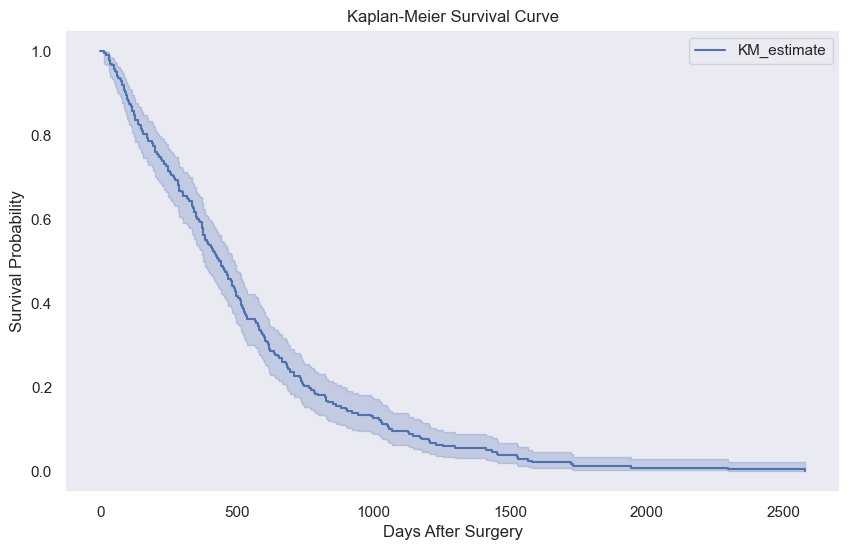

In [97]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Ensure Survival_from_surgery_days_UPDATED is numeric
df_clinical['Survival_from_surgery_days_UPDATED'] = pd.to_numeric(df_clinical['Survival_from_surgery_days_UPDATED'], errors='coerce')

# Encode survival status as 1 (event occurred) and 0 (event not occurred)
df_clinical['event'] = df_clinical['Survival_Status'].apply(lambda x: 1 if x == 'Deceased' else 0)

# Create a Kaplan-Meier Fitter instance
kmf = KaplanMeierFitter()

# Fit the model
kmf.fit(durations=df_clinical['Survival_from_surgery_days_UPDATED'],
        event_observed=df_clinical['event'])

# Plot the Kaplan-Meier curve
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Days After Surgery')
plt.ylabel('Survival Probability')
plt.grid()
plt.show()

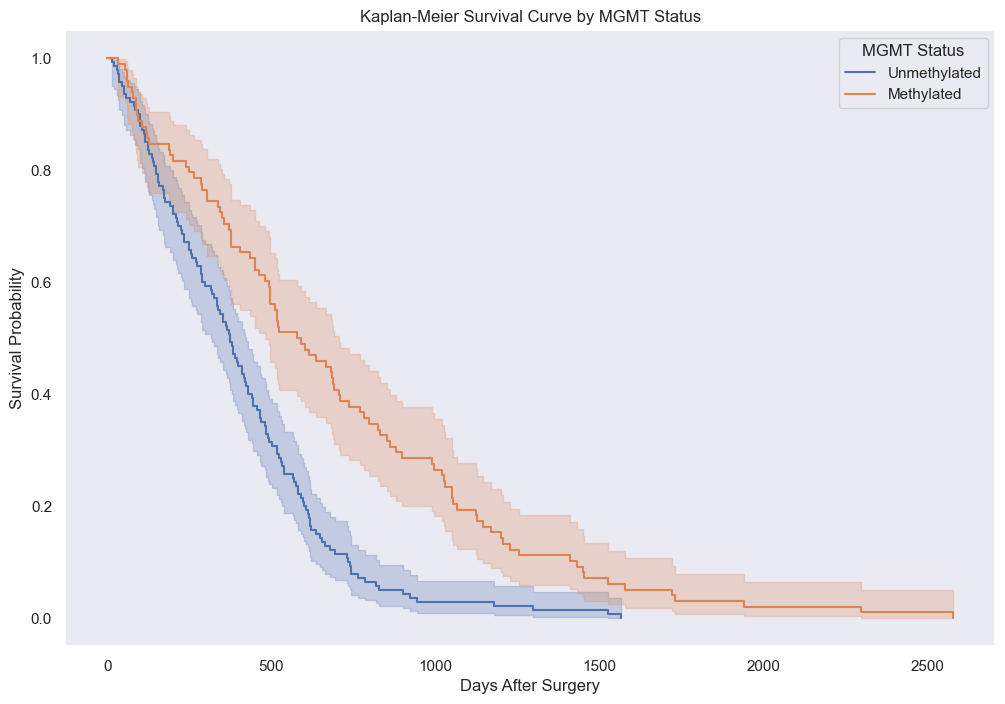

In [98]:
# Ensure Survival_from_surgery_days_UPDATED is numeric
df_clinical['Survival_from_surgery_days_UPDATED'] = pd.to_numeric(df_clinical['Survival_from_surgery_days_UPDATED'], errors='coerce')

# Encode survival status as 1 (event occurred) and 0 (event not occurred)
df_clinical['event'] = df_clinical['Survival_Status'].apply(lambda x: 1 if x == 'Deceased' else 0)

# Create Kaplan-Meier Fitter instance
kmf = KaplanMeierFitter()

# Plotting survival curves for each group
plt.figure(figsize=(12, 8))

# Loop through the unique groups in the MGMT column
for mgmt_status in df_clinical['MGMT'].unique():
    # Create a mask for the current group
    mask = df_clinical['MGMT'] == mgmt_status
    
    # Fit the model
    kmf.fit(durations=df_clinical['Survival_from_surgery_days_UPDATED'][mask],
            event_observed=df_clinical['event'][mask],
            label=mgmt_status)
    
    # Plot the survival function
    kmf.plot_survival_function()

# Decorate the plot
plt.title('Kaplan-Meier Survival Curve by MGMT Status')
plt.xlabel('Days After Surgery')
plt.ylabel('Survival Probability')
plt.grid()
plt.legend(title='MGMT Status')
plt.show()

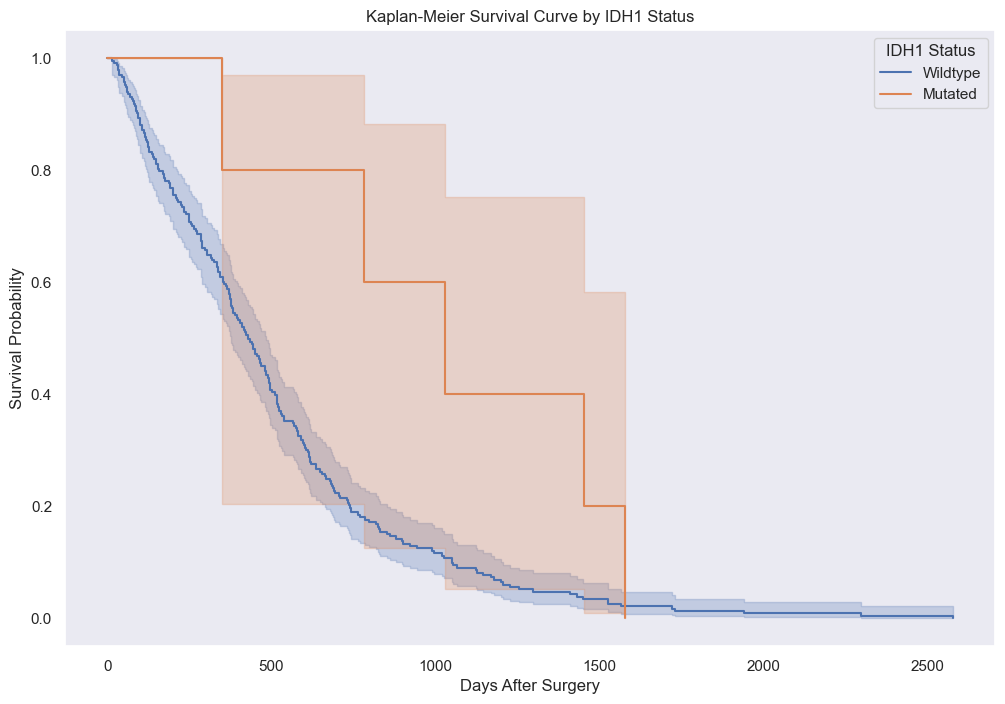

In [99]:
# Ensure Survival_from_surgery_days_UPDATED is numeric
df_clinical['Survival_from_surgery_days_UPDATED'] = pd.to_numeric(df_clinical['Survival_from_surgery_days_UPDATED'], errors='coerce')

# Encode survival status as 1 (event occurred) and 0 (event not occurred)
df_clinical['event'] = df_clinical['Survival_Status'].apply(lambda x: 1 if x == 'Deceased' else 0)

# Create Kaplan-Meier Fitter instance
kmf = KaplanMeierFitter()

# Plotting survival curves for each group
plt.figure(figsize=(12, 8))

# Loop through the unique groups in the MGMT column
for mgmt_status in df_clinical['IDH1'].unique():
    # Create a mask for the current group
    mask = df_clinical['IDH1'] == mgmt_status
    
    # Fit the model
    kmf.fit(durations=df_clinical['Survival_from_surgery_days_UPDATED'][mask],
            event_observed=df_clinical['event'][mask],
            label=mgmt_status)
    
    # Plot the survival function
    kmf.plot_survival_function()

# Decorate the plot
plt.title('Kaplan-Meier Survival Curve by IDH1 Status')
plt.xlabel('Days After Surgery')
plt.ylabel('Survival Probability')
plt.grid()
plt.legend(title='IDH1 Status')
plt.show()

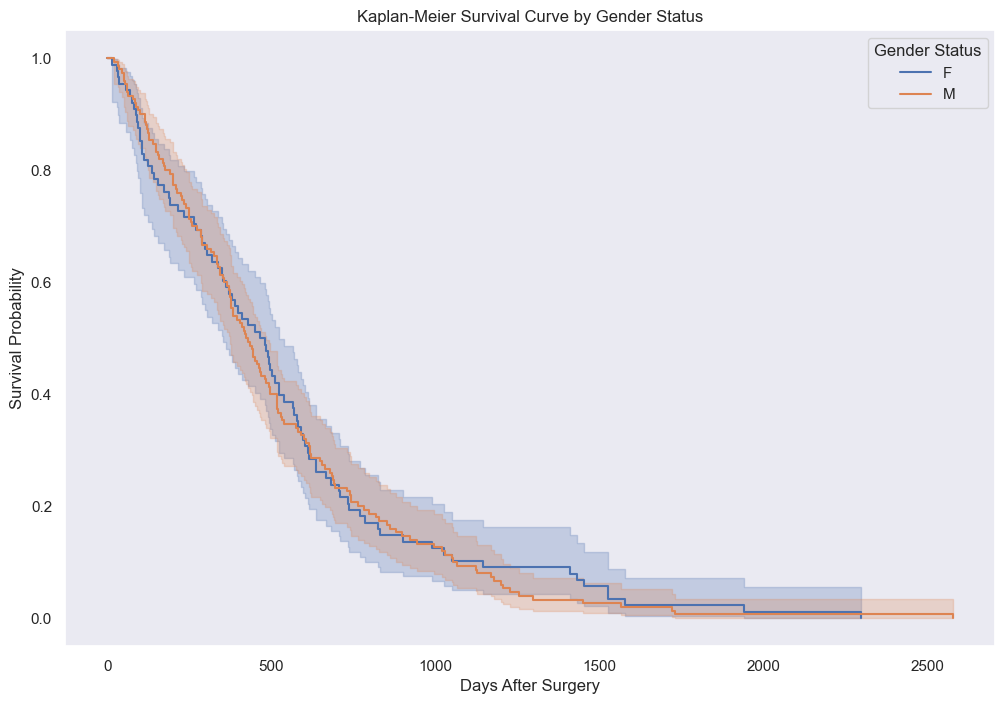

In [100]:
# Ensure Survival_from_surgery_days_UPDATED is numeric
df_clinical['Survival_from_surgery_days_UPDATED'] = pd.to_numeric(df_clinical['Survival_from_surgery_days_UPDATED'], errors='coerce')

# Encode survival status as 1 (event occurred) and 0 (event not occurred)
df_clinical['event'] = df_clinical['Survival_Status'].apply(lambda x: 1 if x == 'Deceased' else 0)

# Drop rows with NaN values in important columns
df_clinical.dropna(subset=['Survival_from_surgery_days_UPDATED', 'event', 'Gender'], inplace=True)

# Create Kaplan-Meier Fitter instance
kmf = KaplanMeierFitter()

# Plotting survival curves for each group
plt.figure(figsize=(12, 8))

# Loop through the unique groups in the MGMT column
for mgmt_status in df_clinical['Gender'].unique():
    # Create a mask for the current group
    mask = df_clinical['Gender'] == mgmt_status
    
    # Fit the model
    kmf.fit(durations=df_clinical['Survival_from_surgery_days_UPDATED'][mask],
            event_observed=df_clinical['event'][mask],
            label=mgmt_status)
    
    # Plot the survival function
    kmf.plot_survival_function()

# Decorate the plot
plt.title('Kaplan-Meier Survival Curve by Gender Status')
plt.xlabel('Days After Surgery')
plt.ylabel('Survival Probability')
plt.grid()
plt.legend(title='Gender Status')
plt.show()

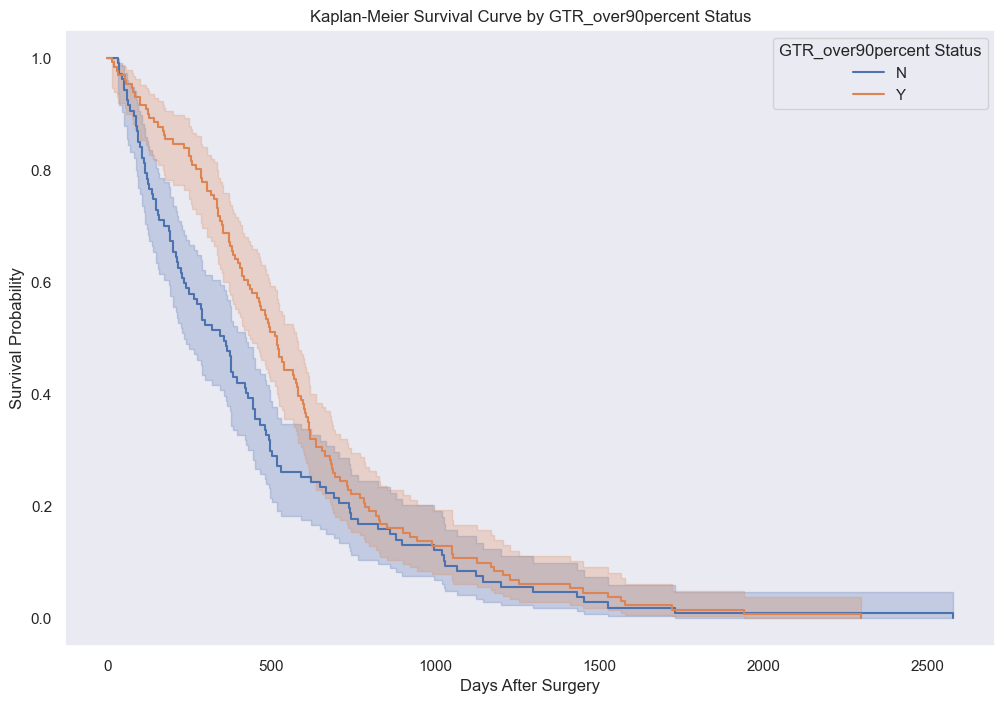

In [101]:
# Ensure Survival_from_surgery_days_UPDATED is numeric
df_clinical['Survival_from_surgery_days_UPDATED'] = pd.to_numeric(df_clinical['Survival_from_surgery_days_UPDATED'], errors='coerce')

# Encode survival status as 1 (event occurred) and 0 (event not occurred)
df_clinical['event'] = df_clinical['Survival_Status'].apply(lambda x: 1 if x == 'Deceased' else 0)

# Create Kaplan-Meier Fitter instance
kmf = KaplanMeierFitter()

# Plotting survival curves for each group
plt.figure(figsize=(12, 8))

# Loop through the unique groups in the GTR_over90percent column
for gtr_status in df_clinical['GTR_over90percent'].unique():
    # Create a mask for the current group
    mask = df_clinical['GTR_over90percent'] == gtr_status
    
    # Fit the model
    kmf.fit(durations=df_clinical['Survival_from_surgery_days_UPDATED'][mask],
            event_observed=df_clinical['event'][mask],
            label=gtr_status)
    
    # Plot the survival function
    kmf.plot_survival_function()

# Decorate the plot
plt.title('Kaplan-Meier Survival Curve by GTR_over90percent Status')
plt.xlabel('Days After Surgery')
plt.ylabel('Survival Probability')
plt.grid()
plt.legend(title='GTR_over90percent Status')
plt.show()

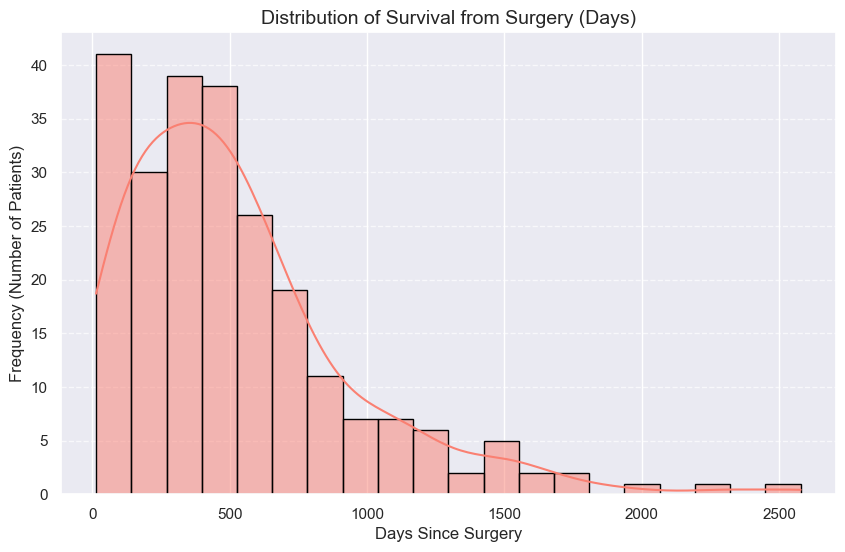

Survival Statistics (Days):
count     238.000000
mean      521.411765
std       419.709150
min        13.000000
25%       217.000000
50%       437.000000
75%       683.250000
max      2578.000000
Name: Survival_from_surgery_days_UPDATED, dtype: float64


In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

#Create the Histogram
plot_data = df_clinical['Survival_from_surgery_days_UPDATED'].dropna()

plt.figure(figsize=(10, 6))

sns.histplot(
    plot_data, 
    bins=20, 
    kde=True, 
    color='salmon',
    edgecolor='black'
)

# Add labels and styling
plt.title('Distribution of Survival from Surgery (Days)', fontsize=14)
plt.xlabel('Days Since Surgery', fontsize=12)
plt.ylabel('Frequency (Number of Patients)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Print summary statistics to help with binning decisions
print("Survival Statistics (Days):")
print(plot_data.describe())

In [103]:
import numpy as np

#Code M and F as binary for Classifier
df_clinical['Gender'] = df_clinical['Gender'].map({'M': 1, 'F': 0})

#Code IDH1 as binary for Classifier
df_clinical['IDH1'] = df_clinical['IDH1'].map({'Mutated': 1, 'Wildtype': 0})

#Code MGMT as binary for Classifier
df_clinical['MGMT'] = df_clinical['MGMT'].map({'Methylated': 1, 'Unmethylated': 0})

#Code GTR as binary for Classifier
df_clinical['GTR_over90percent'] = df_clinical['GTR_over90percent'].map({'N': 1, 'Y': 0})

#Create the "Class" Column for Classifier
bins = [0, 699, np.inf]
labels = [1, 0]

df_clinical['Class'] = pd.cut(df_clinical['Survival_from_surgery_days_UPDATED'], bins=bins, labels=labels)

#retain only desired/relevant data for training
df_clinical = df_clinical.drop(columns=['Survival_from_surgery_days_UPDATED', 'Survival_Status', 'event'])

df_clinical

New Mean: 62.99
New Std:  12.03


,Gender,Age_at_scan_years,IDH1,MGMT,GTR_over90percent,Class
33,0,53.63,0,0,1,1
95,1,47.32,0,0,0,1
99,1,70.54,0,0,1,1
100,0,66.44,0,0,0,1
101,0,51.30,0,0,0,1
...,...,...,...,...,...,...
645,1,60.38,0,0,0,0
646,1,58.12,0,1,0,0
647,0,68.15,0,1,1,0
648,0,79.90,0,1,1,1


Class
1    182
0     56
Name: count, dtype: int64

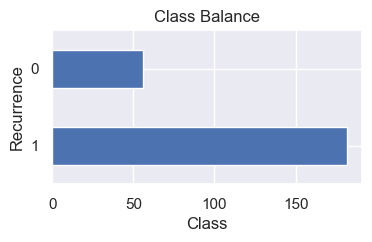

In [104]:
#Class Balance
display(df_clinical['Class'].value_counts())
df_clinical['Class'].value_counts().plot(kind='barh', xlabel='Class', ylabel='Recurrence', title='Class Balance', figsize=(4, 2))
plt.show()

In [105]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.linear_model as lm
## this sets some style parameters
sns.set()


x = df_clinical[['Gender', 'Age_at_scan_years', 'IDH1', 'MGMT', 'GTR_over90percent']]
y = df_clinical['Class']
trainFraction = .75

## Once again hold out some data
sample = np.random.uniform(size = 238) < trainFraction
xtrain = x[ sample]
ytrain = y[ sample]
xtest =  x[~sample]
ytest =  y[~sample]

In [106]:
lr = lm.LogisticRegression(fit_intercept=True, class_weight='balanced')
fit = lr.fit(xtrain, ytrain)

In [108]:
## This predicts the classes using a 50% probability cutoff
yhat_test = fit.predict(xtest)

accuracy = np.mean(yhat_test == ytest)
sensitivity = np.mean(yhat_test[ytest == 1] == ytest[ytest == 1])
specificity = np.mean(yhat_test[ytest == 0] == ytest[ytest == 0])
np.round([accuracy, sensitivity, specificity], 3)


array([0.763, 0.755, 0.8  ])

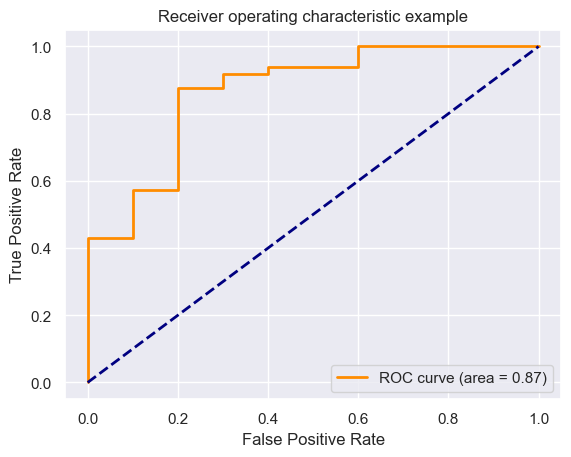

In [109]:
from sklearn.metrics import accuracy_score, roc_curve, auc

ptest = fit.predict_proba(xtest)[:, 1]
fpr, tpr, thresholds = roc_curve(ytest, ptest)
roc_auc = auc(fpr, tpr)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()


In [116]:
import joblib

# 'fit' is the name of your LogisticRegression model from your notebook
# 'trained_model.pkl' is the filename the Streamlit app is looking for
joblib.dump(fit, 'trained_model.pkl')

print("Model saved successfully as 'trained_model.pkl'")

Model saved successfully as 'trained_model.pkl'
